In [2]:
#----------------------------------------------------------------------#
#                     EXAMPLE 0 (1D PROBLEM).                          #
#                                                                      #
#   This program solve the Poisson equation:                           #
#   Este programa resuleve la ecuacón de Poisson:                      #
#                 u_xx =  f,  x en (xI,xF).                            #
#   con condición de frontera tipo Dirichlet                           #
#                 u(-1) = 0 and u(1) = 0                               #
#   La solución exacta es:                                             #
#                      u(x,y) = sin(pi*x)                              #
#----------------------------------------------------------------------#
#  Citar como:                                                         #
#----------------------------------------------------------------------#

# Importación de bibliotecas necesarias para el modelo y visualización

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import time
from pathlib import Path
import json
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# Configuración global
# ============================================================
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# Problema exacto
# ============================================================
def u_exact(x):
    return torch.sin(torch.pi * x)


def rhs(x):
    return -(torch.pi ** 2) * torch.sin(torch.pi * x)


# ============================================================
# Red neuronal flexible
# ============================================================
class FlexibleMLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(layers[i], layers[i + 1])
            for i in range(len(layers) - 1)
        ])

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        return self.layers[-1](x)


# ============================================================
# PDE residual
# ============================================================
def pde(x, model):
    x = x.clone().detach().requires_grad_(True)

    u = model(x)

    du_dx = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2u_dx2 = torch.autograd.grad(
        du_dx, x,
        grad_outputs=torch.ones_like(du_dx),
        create_graph=True
    )[0]

    return d2u_dx2 - rhs(x)


# ============================================================
# Loss
# ============================================================
def loss_fn(model, x_interior, x_bc, y_bc):
    loss_pde = torch.mean(pde(x_interior, model) ** 2)

    pred_bc = model(x_bc)
    loss_bc = torch.mean((pred_bc - y_bc) ** 2)

    return loss_pde + loss_bc


# ============================================================
# Datos
# ============================================================
def generate_training_data(xI=-1.0, xF=1.0, nf=10):
    # interior
    x_train = np.linspace(xI, xF, nf).reshape(-1, 1)
    x_train = torch.tensor(x_train, dtype=torch.float32).to(device)

    # boundary
    x_bc = torch.tensor([[xI], [xF]], dtype=torch.float32).to(device)
    y_bc = u_exact(x_bc)

    return x_train, x_bc, y_bc


# ============================================================
# Error máximo absoluto
# ============================================================
@torch.no_grad()
def compute_max_error(model, xI=-1.0, xF=1.0, n_test=200):
    x_test = torch.linspace(xI, xF, n_test).reshape(-1, 1).to(device)

    pred = model(x_test)
    exact = u_exact(x_test)

    max_error = torch.max(torch.abs(pred - exact)).item()
    return max_error


# ============================================================
# Entrenamiento de una corrida
# ============================================================
def train_once(
    layers=[1, 50, 50, 50, 50, 1],
    epochs=2000,
    lr=1e-3,
    nf=10,
    alpha=1e-4,
    beta=1e-3,
    verbose=False,
    save_path=None
):
    model = FlexibleMLP(layers).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    x_train, x_bc, y_bc = generate_training_data(nf=nf)

    final_loss = None
    max_error = None
    success = False
    history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        loss = loss_fn(model, x_train, x_bc, y_bc)
        loss.backward()
        optimizer.step()

        final_loss = loss.item()
        max_error = compute_max_error(model)
        success = (final_loss < alpha) and (max_error < beta)

        history.append({
            "epoch": epoch + 1,
            "loss": final_loss,
            "max_error": max_error,
            "success": success
        })

        if verbose and (epoch % 200 == 0 or success):
            print(f"Epoch {epoch+1}: loss = {final_loss:.3e}, err = {max_error:.3e}")

        if success:
            if verbose:
                print(f"Éxito en epoch {epoch+1}. Deteniendo entrenamiento.")

            if save_path is not None:
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch + 1,
                    "loss": final_loss,
                    "max_error": max_error,
                    "success": success,
                    "history": history
                }, save_path)

            break

    return model, final_loss, max_error, success, history


# ============================================================
# Experimento múltiple
# ============================================================
def run_experiment(
    n_runs=100,
    alpha=1e-4,
    beta=1e-3,
    layers=[1, 50, 50, 50, 50, 1],
    epochs=2000,
    lr=1e-3,
    nf=10,
    verbose=False,
    exp_name="exp_01"
):
    # Carpeta del experimento
    BASE_DIR = "/content/drive/MyDrive/PINN_experiments"
    exp_dir = Path(BASE_DIR) / exp_name
    exp_dir.mkdir(parents=True, exist_ok=True)

    # Guardar configuración del experimento
    config = {
        "n_runs": n_runs,
        "alpha": alpha,
        "beta": beta,
        "layers": layers,
        "epochs": epochs,
        "lr": lr,
        "nf": nf
    }
    with open(exp_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4)

    successes = 0
    results = []

    for run in range(n_runs):
        save_path = exp_dir / f"model_run_{run+1:03d}.pt"

        model, final_loss, max_error, success, history = train_once(
            layers=layers,
            epochs=epochs,
            lr=lr,
            nf=nf,
            alpha=alpha,
            beta=beta,
            verbose=False,
            save_path=str(save_path)
        )

        if success:
            successes += 1

        results.append({
            "run": run + 1,
            "loss": final_loss,
            "max_error": max_error,
            "success": success,
            "epochs_used": len(history)
        })

        # Guardado incremental
        pd.DataFrame(results).to_csv(exp_dir / "results_experiment.csv", index=False)

        if verbose:
            status = "OK" if success else "FAIL"
            print(
                f"Run {run+1:03d} | loss={final_loss:.3e} | "
                f"err={max_error:.3e} | {status} | epochs={len(history)}"
            )

    success_rate = 100 * successes / n_runs

    print("\n" + "=" * 60)
    print(f"Experimento    : {exp_name}")
    print(f"Total runs     : {n_runs}")
    print(f"Successful runs : {successes}")
    print(f"Success rate   : {success_rate:.2f}%")
    print(f"Carpeta        : {exp_dir}")
    print("=" * 60)

    return results

In [ ]:
# ============================================================
# Ejecutar
# ============================================================
results = run_experiment(
    n_runs=100,
    alpha=1e-4,
    beta=1e-3,
    layers=[1, 50, 50, 50, 50, 1],
    epochs=3000,
    lr=1e-3,
    nf=10,
    verbose=True,
    exp_name="exp_02_3000_epochs"
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Run 001 | loss=1.129e-07 | err=7.974e-04 | OK | epochs=2838
Run 002 | loss=4.415e-06 | err=9.667e-04 | OK | epochs=1333
Run 003 | loss=2.550e-06 | err=9.678e-04 | OK | epochs=1434
Run 004 | loss=6.314e-07 | err=7.592e-04 | OK | epochs=1450
Run 005 | loss=1.482e-06 | err=9.290e-04 | OK | epochs=1489
Run 006 | loss=1.009e-05 | err=9.759e-04 | OK | epochs=2239
Run 007 | loss=7.881e-07 | err=9.408e-04 | OK | epochs=2032
Run 008 | loss=1.991e-07 | err=9.577e-04 | OK | epochs=2365
Run 009 | loss=8.695e-05 | err=7.045e-04 | OK | epochs=1301
Run 010 | loss=9.970e-05 | err=9.899e-04 | OK | epochs=355
Run 011 | loss=2.647e-07 | err=8.913e-04 | OK | epochs=1776
Run 012 | loss=6.019e-05 | err=9.900e-04 | OK | epochs=287


Primeras corridas:


,run,loss,max_error,success,epochs_used
0,1,4.008944e-05,0.000922,True,238
1,2,2.385545e-07,0.000896,True,1951
2,3,5.434094e-07,0.000954,True,2651
3,4,5.251584e-05,0.000928,True,1516
4,5,1.455133e-06,0.000981,True,2016



Resumen global:


,Metric,Value
0,Total runs,100.000000
1,Successful runs,100.000000
2,Failed runs,0.000000
3,Success rate (%),100.000000
4,Mean loss,0.000020
5,Median loss,0.000002
6,Mean max error,0.000926
7,Median max error,0.000950



Estadísticas descriptivas:


,loss,max_error
count,1.000000e+02,100.000000
mean,2.040553e-05,0.000926
std,3.298695e-05,0.000074
min,3.713748e-08,0.000677
25%,7.903537e-07,0.000895
50%,2.323874e-06,0.000950
75%,2.054411e-05,0.000981
max,9.989673e-05,0.001000



Conteo éxito/fallo:


,success,count
0,True,100


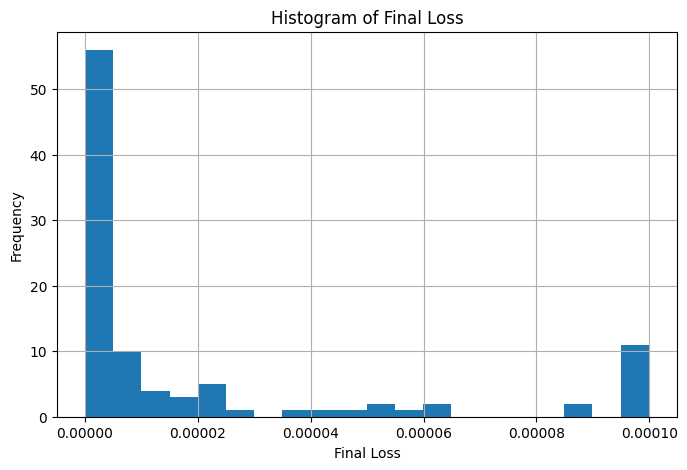

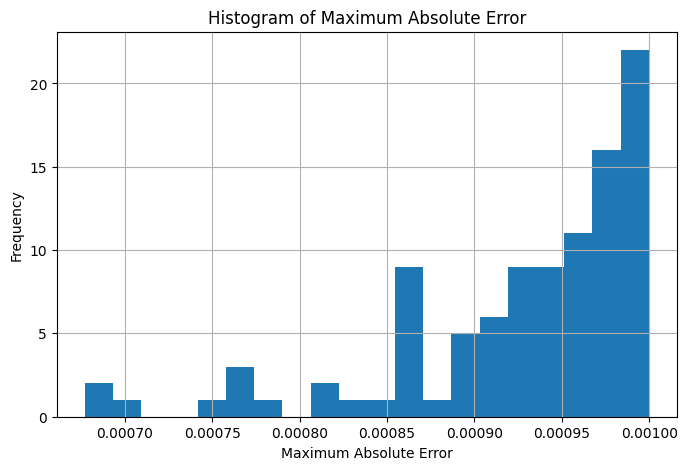

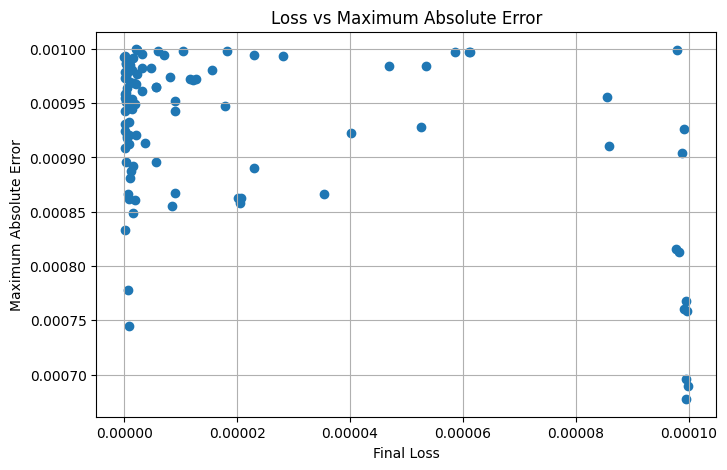


Archivo guardado: results_experiment.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Convertir resultados a DataFrame
# ============================================================
df = pd.DataFrame(results)

# Mostrar primeras filas
print("Primeras corridas:")
display(df.head())

# ============================================================
# Tabla resumen
# ============================================================
summary = pd.DataFrame({
    "Metric": [
        "Total runs",
        "Successful runs",
        "Failed runs",
        "Success rate (%)",
        "Mean loss",
        "Median loss",
        "Mean max error",
        "Median max error"
    ],
    "Value": [
        len(df),
        df["success"].sum(),
        (~df["success"]).sum(),
        100 * df["success"].mean(),
        df["loss"].mean(),
        df["loss"].median(),
        df["max_error"].mean(),
        df["max_error"].median()
    ]
})

print("\nResumen global:")
display(summary)

# ============================================================
# Estadísticas descriptivas
# ============================================================
print("\nEstadísticas descriptivas:")
display(df[["loss", "max_error"]].describe())

# ============================================================
# Conteo éxito/fallo
# ============================================================
success_table = df["success"].value_counts().rename_axis("success").reset_index(name="count")

print("\nConteo éxito/fallo:")
display(success_table)

# ============================================================
# Histograma loss
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(df["loss"], bins=20)
plt.xlabel("Final Loss")
plt.ylabel("Frequency")
plt.title("Histogram of Final Loss")
plt.grid(True)
plt.show()

# ============================================================
# Histograma error máximo
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(df["max_error"], bins=20)
plt.xlabel("Maximum Absolute Error")
plt.ylabel("Frequency")
plt.title("Histogram of Maximum Absolute Error")
plt.grid(True)
plt.show()

# ============================================================
# Scatter loss vs error
# ============================================================
plt.figure(figsize=(8, 5))
plt.scatter(df["loss"], df["max_error"])
plt.xlabel("Final Loss")
plt.ylabel("Maximum Absolute Error")
plt.title("Loss vs Maximum Absolute Error")
plt.grid(True)
plt.show()

# ============================================================
# Guardar CSV opcional
# ============================================================
df.to_csv("results_experiment.csv", index=False)
print("\nArchivo guardado: results_experiment.csv")